In [1]:
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

DB = '../data/humans_clean.sqlite3'

conn = sqlite3.connect(DB)
conn.execute('PRAGMA cache_size=-500000')

cur = conn.execute("""
    SELECT
        CASE
            WHEN impact_date LIKE '-%'
                THEN (CAST(SUBSTR(impact_date, 1, 5) AS INTEGER) / 100) * 100
            ELSE (CAST(SUBSTR(impact_date, 1, 4) AS INTEGER) / 100) * 100
        END AS century,
        COUNT(*) as cnt
    FROM individuals_impact_date
    GROUP BY century
    ORDER BY century
""")
rows = cur.fetchall()
conn.close()

data = [(c, n) for c, n in rows if -3500 <= c <= 2000]
centuries = [r[0] for r in data]
counts = [r[1] for r in data]

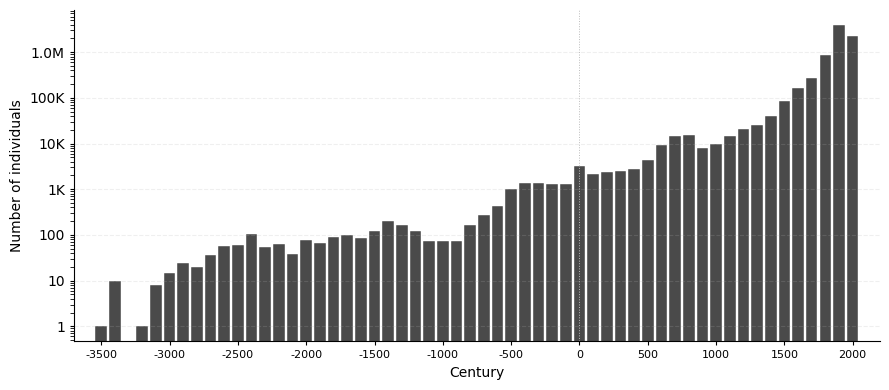

In [2]:
fig, ax = plt.subplots(figsize=(9, 4))

ax.bar(centuries, counts, width=85, color='#4a4a4a', edgecolor='white', linewidth=0.3)

ax.set_yscale('log')
ax.set_xlabel('Century')
ax.set_ylabel('Number of individuals')
ax.set_xlim(-3700, 2200)

xticks = list(range(-3500, 2500, 500))
ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks], fontsize=8)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K' if x >= 1e3 else f'{x:.0f}'
))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='both', length=3)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.axvline(x=0, color='#bbbbbb', linestyle=':', linewidth=0.7)

plt.tight_layout()
plt.show()